# Quantum Oracle Sketching for Boolean Functions

> **Quantum Oracle Sketching** is a data-loading algorithm introduced by Zhao et al. [[1]](#ref1). It provides the missing link between classical data access and the *coherent oracle queries* on which many powerful quantum algorithms are built.
>
> The algorithm approximates the desired oracle $O_f$ on the fly from a stream of classical samples $(x_t, f(x_t))$, applying an incremental data-dependent rotation per sample and discarding each sample once consumed. At no point is the dataset stored in either classical or quantum memory. The result is an exponential advantage in space complexity over any classical learner; and when the data distribution varies in time while the learner stays fixed, a super-polynomial advantage in sample complexity is obtained as well: a classical machine requires the number of data examples to scale super-polynomially with the data size $N$, while a quantum learner only needs an amount of data that scales linearly, achieving matching accuracy and probabilistic performance.
>
> The algorithm treats the following problem:
>
> - **Input**: $M$ classical data samples $\{(x_t, f(x_t))\}_{t=1}^{M}$, where each $x_t \in [N] = \{0,1,\dots,N-1\}$ is drawn independently from a (possibly time-varying) distribution $p$, and $f$ is the target Boolean function ($f[N]\rightarrow \{0,1\}$). 
> - **Output:** A quantum unitary $V$ on $n = \lceil\log_2 N\rceil$ qubits that approximates the corresponding *coherent* query oracle $O$, the phase oracle $|x\rangle \to (-1)^{f(x)}|x\rangle$, or a real valued phase $|x\rangle \to e^{i \theta_x}|x\rangle$ to error $\epsilon$ in diamond distance. 
>
> **Extensions**: Here we consider a Boolean function. Nevertheless, the method can be generalized for multi-bit Boolean output real-valued functions ($f:[N]\to \mathbb{R}$), state preparation (input $(j, b_j)$, encoding the index $j$ and value $b_j$ of a vector element) oracles, and block-encodings of matrices (input is a tuple $(i, j, A_{ij})$, encoding the elements of a matrix $A$). $V$ can then be used as a drop-in subroutine inside any quantum query algorithm.
>
> **Complexity**
>
> - **Sample complexity**: A single $\epsilon$-accurate oracle sketch requires $M = \Theta(N/\epsilon)$ classical samples. To support an arbitrary quantum algorithm that makes $Q$ queries to total error $\epsilon$, each query is sketched to error $\epsilon/Q$, giving
> $$ M_\text{total} = \Theta\!\bigl(N Q^2 / \epsilon\bigr). $$
> The quadratic dependence on $Q$ is unavoidable, mirroring the Born-rule relationship between quantum amplitudes and probabilities.
> - **Space complexity**: $\mathcal{O}(\mathrm{poly}\log N)$ qubits — the quantum machine never stores the dataset, only its current quantum state.
> - **Time complexity**: $\widetilde{\mathcal{O}}(N)$ in the data-loading stage (one constant-depth controlled gate per sample); subsequent processing of each sample requires only $\mathrm{poly}\log N$ time. Here the overscript tilde designates possible hidden logarithmic dependencies in $N$.
> - **Classical lower bound (dynamic case)**: Any classical machine of size ${\cal{O}}(N^{0.99})$ that matches the quantum prediction accuracy on a time-varying distribution, requires a super-polynomial number of samples.
>
> ---
>
> **Keywords:** Quantum Learning Theory, Quantum Machine Learning (QML), Streaming Algorithms

## Introduction

Most quantum speedup over a classical baseline is stated relative to an *oracle*, a unitary $O_f$ that encodes the input function $f$ and acts in superposition. [Grover's search](https://github.com/Classiq/classiq-library/blob/main/algorithms/search_and_optimization/grover/grover.ipynb) assumes a phase oracle $O_f|x\rangle = (-1)^{f(x)}|x\rangle$; the [HHL linear-system solver](https://github.com/Classiq/classiq-library/blob/main/algorithms/quantum_linear_solvers/hhl/hhl.ipynb) [[5]](#ref5), [quantum singular-value transformation (QSVT)](https://github.com/Classiq/classiq-library/blob/main/algorithms/quantum_linear_solvers/qsvt_matrix_inversion/qsvt_matrix_inversion.ipynb) [[4]](#ref4), and most quantum machine-learning routines rely on a block-encoding oracle for the input matrix; [amplitude estimation](https://github.com/Classiq/classiq-library/blob/main/algorithms/amplitude_amplification_and_estimation/oblivious_amplitude_amplification/oblivious_amplitude_amplification.ipynb) and quantum walks similarly assume coherent access to the input. This *coherent* access, the ability to evaluate $f$ on a superposition of inputs in a single query, is exactly what enables the quadratic and exponential speedups, without it, an in-depth analysis shows that the algorithms collapse to their classical counterparts.

Yet real-world classical data, produced one sample at a time by experiments, sensors, or users, does not natively support such queries. The standard remedy is to load the entire dataset into a quantum random-access memory (QRAM [[3]](#ref3)), but its fault-tolerance overhead often exceeds the quantum advantage it enables, leaving the most powerful quantum algorithms without a practical interface to massive classical data.

Quantum oracle sketching is the algorithm that closes this gap: it constructs an approximate $O_f$ on the fly from a stream of classical samples, with no QRAM and no full dataset ever held in memory.

## The streaming-learning framework

Quantum oracle sketching is proposed in the context of a specific online-learning model. The framework sets the rules under which both the quantum and the classical baselines operate, and it explains why the comparison between the two is well-posed.

**Setup.**

- A *data-generating process* $\mathcal{D}$ emits a sequence of classical samples $z_1, z_2, \dots, z_M$. Each sample is one observation of the underlying object — a function value $z_t = (x_t, f(x_t))$ for a Boolean target, a feature-vector / label pair $z_t = (i_t, \vec{x}_{i_t}, y_{i_t})$ for classification, or an entry $z_t = (i_t, j_t, A_{i_t j_t}, k_t, b_{k_t})$ of a linear system $A\vec{x} = \vec{b}$.
- A *learner* of size $S$ (which can be the number of logical qubits composing the quantum learner, or the number of floating-point words for a classical one) observes the samples *one at a time*. After seeing $z_t$ it updates its memory, then discards $z_t$. At no point is the dataset stored in full. This is known as *streaming* model.
- After $M$ samples, the learner is asked to predict, classify, or compress some property of the underlying process $\mathcal{D}$ (not of the empirical sample!). Examples: the label of a held-out test feature vector (classification), the value of a quadratic form $\vec{x}^\top \mathcal{M} \vec{x}$ (linear systems), or the projection of a test point onto the top principal direction (PCA).

The two resources of interest are the *machine size* $S$ and the *sample count* $M$. Optimally, we would like to minimize both simultaneously.

**Static versus dynamic data.** The framework allows the data distribution to drift in time, characterized by two parameters:

- *Refreshing time* $\tau$: the timescale beyond which samples become effectively uncorrelated.
- *Repetition number* $R$: the maximum expected number of times any single sample is repeated within a window of $\tau$ steps.

When $\tau \to \infty$ we recover the static, i.i.d. setting. When $\tau = \widetilde{\mathcal{O}}(N)$ the distribution refreshes on the same timescale as the data size, and the quantum advantage in sample complexity becomes *super-polynomial*. In this regime, any $\Omega(N^{0.99})$-size classical machine needs super-polynomially many samples while a quantum learner with $\mathrm{poly}\log N$ qubits suffices with $\widetilde{\mathcal{O}}(N)$ samples.

**End-to-end pipeline.** The full quantum learner is a three-stage assembly:

1. **Quantum oracle sketching** consumes the stream of classical samples and produces an approximate oracle unitary $V \approx O_f$ (the subject of the present notebook).
2. A **quantum query algorithm** — Grover, QSVT [[4]](#ref4), HHL [[5]](#ref5), amplitude estimation, etc. — uses $V$ as a black-box subroutine to prepare a target state $|\psi_\text{target}\rangle$ that encodes the desired property of $\mathcal{D}$.
3. **Interferometric classical shadows** — a sign-preserving variant of the Classical Shadow Tomography protocol [[2]](#ref2). The method extracts a compact classical model from $|\psi_\text{target}\rangle$ in $\mathrm{poly}\log N$ measurements, ready for offline prediction on arbitrary test inputs.

This notebook focuses on the first stage of this scheme, covering the variants of the quantum oracle sketching of a Boolean function.

## Implementation of the Oracle Sketching Algorithm

### Oracle Sketching of a Boolean Function and Uniform Distribution

We aim to implement the Boolean phase oracle

$$
O\,|x\rangle = (-1)^{f(x)}\,|x\rangle, \qquad x \in [N],\ f : [N] \to \{0,1\},
$$

given only random classical samples $z_t = (x_t,\, f(x_t))$ for $t = 1,\dots,M$, where each $x_t$ is drawn uniformly from $[N] = \{0,1,\dots,N-1\}$.

**Per-sample rotation.** For each sample we apply a small data-dependent phase rotation that fires only on the basis state $|x_t\rangle$:

$$
V_t \;=\; \exp\!\bigl(i\,\tau\, f(x_t)\,|x_t\rangle\!\langle x_t| / M\bigr). \tag{1}
$$

**Coherent accumulation.** Because every $V_t$ is diagonal in the computational basis, all factors commute and the product collapses cleanly:

$$
V \;\equiv\; \prod_{t=1}^M V_t \;=\; \exp\!\Bigl(i\tfrac{\tau}{M}\sum_{t=1}^M f(x_t)\,|x_t\rangle\!\langle x_t|\Bigr) \;=\; \sum_{x=0}^{N-1} \exp\bigl(i\,\tau\, m_x\, f(x)\bigr)\,|x\rangle\!\langle x|, \tag{2}
$$

where $m_x = \frac{1}{M}\sum_t \mathbf{1}[x_t = x]$ is the empirical frequency of basis label $x$.

**Concentration.** As $M$ grows, $m_x \to p(x) = 1/N$ by the law of large numbers. Picking $\tau = \pi N$ makes $\tau\, m_x \to \pi$ and

$$
V \;\longrightarrow\; \sum_{x=0}^{N-1} e^{i\pi f(x)}\,|x\rangle\!\langle x| \;=\; \sum_x (-1)^{f(x)}\,|x\rangle\!\langle x| \;=\; O. \tag{3}
$$

**Sample complexity.** Ref. [[1]](#ref1) shows the diamond-distance error decays as $\epsilon = \mathcal{O}(N/M)$, so reaching error $\epsilon$ costs

$$
M = \Theta(N/\epsilon) \tag{4}
$$

samples. Each sample is processed once and immediately discarded.

**Comparison to generic random Hamiltonian simulation.** The $N/M$ scaling above is *not* what a naive random-rotation strategy would deliver. If one instead applied a sequence of small phases $\exp(i\,\tau\, h_{z_t}/M)$ driven by an arbitrary Hamiltonian $h_z$ with $\|h_z\| = \mathcal{O}(1)$ — hoping the sequence approximates $\exp(i\,\tau\,\mathbb{E}[h_z])$, randomized-Hamiltonian-simulation results show the operator-norm error compounds to

$$
\epsilon_\text{naive} \;=\; \mathcal{O}(N^2 / M),\qquad \text{i.e.}\qquad M_\text{naive} \;=\; \Theta(N^2 / \epsilon).
$$

That extra factor of $N$ would consume the entire quantum advantage. To support $Q$ queries with combined error $\epsilon$, each individual query must be sketched to error $\epsilon/Q$, so per-query naive simulation needs $\Theta(N^2 Q / \epsilon)$ samples and the total becomes

$$
M_\text{total}^\text{naive} \;=\; Q \cdot \Theta(N^2 Q/\epsilon) \;=\; \Theta(N^2 Q^2/\epsilon),
$$

versus the $\Theta(NQ^2/\epsilon)$ achieved here — a factor-$N$ blow-up that would take $\widetilde{\mathcal{O}}(N)$-sample tasks straight back into the regime where any classical machine of size $\Omega(N^{0.99})$ wins. The improvement to $\epsilon = \mathcal{O}(N/M)$ comes from a crucial piece of structure: each $V_t$ phases only the *one-dimensional* subspace $|x_t\rangle\!\langle x_t|$, and distinct values of $x$ label *mutually orthogonal* subspaces, so per-sample errors live in disjoint Hilbert-space blocks rather than compounding across the full register. Quantum oracle sketching is, in this sense, a carefully engineered *non-generic* instance of randomized Hamiltonian simulation, designed precisely to dodge the $N^2/M$ trap.

We begin by importing the required python modules and define the size of the problem $N$ and the truth table, defining $f$.

In [10]:
!pip install 'classiq[qsp]'

import matplotlib.pyplot as plt
import numpy as np

from classiq import *
from classiq.applications.qsp import qsp_approximate, qsvt_phases

np.random.seed(7)


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [11]:
N = 8  # problem size; the register has int(log2(N)) qubits

# A random Boolean target function f: [N] -> {0, 1}
F_TABLE = np.random.randint(0, 2, size=N)
print(f"f(x) for x = 0,...,{N-1}:  {F_TABLE.tolist()}")

f(x) for x = 0,...,7:  [1, 0, 1, 0, 1, 1, 1, 1]


We begin by introducing the basic quantum functions, which are utilized to construct the quantum oracle sketching function. The primitive `apply_basis_phase` realizes $\exp(i\theta\,|x_\text{int}\rangle\!\langle x_\text{int}|)$ by controlling on the equality predicate `qvar == x_int`; the body `phase(theta)` becomes a relative phase on the controlled subspace and the identity elsewhere, which is exactly $V_t$. 
The `quantum_oracle_sketch_boolean` function iterates over the samples of `x_samples`, leading to an approximate application of $O_f$.

In [12]:
@qfunc
def apply_basis_phase(theta: CReal, x_int: CInt, qvar: QNum) -> None:
    """Apply ``exp(i · θ · |x_int⟩⟨x_int|)`` on ``qvar``.

    Implemented by controlling on the equality predicate ``qvar == x_int``;
    the inner ``phase(θ)`` becomes a relative phase on the controlled
    subspace and the identity elsewhere, which is exactly ``V_t``.
    """
    control(qvar == x_int, lambda: phase(theta))


@qfunc
def quantum_oracle_sketch_boolean(
    theta: CReal, x_samples: CArray[CInt], qvar: QNum
) -> None:
    """Sketched Boolean phase oracle ``V = ∏_t exp(i θ |x_t⟩⟨x_t|)``.

    ``x_samples`` should be pre-filtered to the indices with ``f(x_t) = 1``;
    a single fixed angle ``θ = π N / M`` is then applied per sample.
    """
    repeat(
        count=x_samples.len,
        iteration=lambda t: apply_basis_phase(theta, x_samples[t], qvar),
    )

We pre-filter the classical data so only samples with $f(x_t)=1$ enter the circuit (the rest contribute the identity), fix $\theta = \pi N / M$, and bake the samples into the circuit at synthesis time. The leading Hadamard transform lets us see the diagonal-phase action of $V$ on the uniform superposition $|+\rangle^{\otimes n}$.

In [13]:
# For circuit synthesis we use a smaller M so the visualization stays readable;
# the numpy benchmark below validates the algorithm at larger M.
M_demo = 200
demo_samples = np.random.randint(0, N, size=M_demo)
positive_samples = demo_samples[F_TABLE[demo_samples] == 1].tolist()
theta = np.pi * N / M_demo  # τ / M with τ = π N
n_qubits = int(np.log2(N))


@qfunc
def main(qvar: Output[QNum]) -> None:
    allocate(n_qubits, qvar)
    hadamard_transform(qvar)
    quantum_oracle_sketch_boolean(theta, positive_samples, qvar)


qprog = synthesize(main)
show(qprog)

Quantum program link: https://platform.classiq.io/circuit/3EcNPD6xePNwRJeICQwSJWn2AxA


**Verification on a 2-qubit Bell state via Classiq execution.**

Take $f = [0, 0, 1, 1]$ — a phase on the most-significant-bit subspace. The ideal oracle maps $|\Phi^+\rangle = (|00\rangle + |11\rangle)/\sqrt{2}$ to $|\Phi^-\rangle = (|00\rangle - |11\rangle)/\sqrt{2}$. We prepare $|\Phi^+\rangle$ on a 2-qubit register, apply the sketched `quantum_oracle_sketch_boolean` for one random sample sequence of $M = 500$ samples, then run the *inverse* Bell preparation (CX followed by H on qubit 0) so that the Bell basis is rotated back to the computational basis: in particular $|\Phi^-\rangle \mapsto |10\rangle$ (i.e. `qvar = 1`). Measuring the register in the computational basis with `sample(...)` helper then makes the fidelity $|\langle\Phi^-|V|\Phi^+\rangle|^2$ equal to the probability of observing `qvar = 1`. The single-realization error scales as $\sqrt{N/M}$, so the fidelity gap from $1$ is of order $N/M \approx 0.008$ on average over realizations, with typical per-shot fluctuations of order $\sqrt{N/M} \approx 0.09$.

In [14]:
from classiq.execution import sample

# 2-qubit Bell-state setup: f = [0,0,1,1] phases the MSB subspace.
N_ex, M_ex = 4, 500
F_ex = np.array([0, 0, 1, 1])
theta_ex = np.pi * N_ex / M_ex

np.random.seed(0)
demo_samples_ex = np.random.randint(0, N_ex, size=M_ex)
positive_samples_ex = demo_samples_ex[F_ex[demo_samples_ex] == 1].tolist()


@qfunc
def main(qvar: Output[QNum]) -> None:
    bell = QArray[QBit, 2]()
    allocate(2, qvar)
    # 1) Prepare |Φ+⟩.
    # 2) Apply the sketched oracle on the QNum view.
    # 3) Inverse Bell prep — rotates the Bell basis to the computational basis,
    #    in particular |Φ-⟩ → |10⟩ (qvar = 1).
    within_apply(
        within=lambda: (
            bind(qvar, bell),  # qvar (initialised) → bell
            H(bell[0]),
            CX(bell[0], bell[1]),
            bind(bell, qvar),  # bell → qvar so the oracle sees a QNum
        ),
        apply=lambda: quantum_oracle_sketch_boolean(
            theta_ex, positive_samples_ex, qvar
        ),
    )


qprog_bell = synthesize(main)

df = sample(qprog_bell, "simulator", num_shots=10_000)

fidelity = float(df.loc[df["qvar"] == 1, "probability"].sum())
print(f"Fidelity |⟨Φ-|V|Φ+⟩|² at M={M_ex}:  {fidelity:.4f}")

Submitting job to simulator
Job: https://platform.classiq.io/jobs/3049c095-514b-426a-b278-8dadf42ab970


Fidelity |⟨Φ-|V|Φ+⟩|² at M=500:  0.9620


### Verification of the sample-complexity scaling

In order to verify the sample complexity, we build the sketched unitary $V$ classically by collecting $M$ random samples and assembling the diagonal matrix from eq. (2). Following, we compare the results to the theory and evaluate the scaling constants (hidden by the big-O notation).

Two scalings of the error to the ideal oracle $O$ are worth keeping distinct:

- **Single-realization** operator-norm error $\|V_\lambda - O\|_2$ for one random data sample $\lambda = (x_1, \dots, x_M)$ is dominated by the *variance* of the empirical frequencies $|m_x - 1/N| = \mathcal{O}(1/\sqrt{NM})$. Each diagonal entry deviates by $\pi N|m_x - 1/N| \sim \sqrt{N/M}$, so the spectral norm scales as $\|V_\lambda - O\|_2 = \mathcal{O}(\sqrt{N/M})$.

- **Random-unitary channel** $\mathcal{C}(\rho) = \mathbb{E}_\lambda[V_\lambda\, \rho\, V_\lambda^\dagger]$ — the actual object that gets used inside any quantum query algorithm — has diamond-distance error $\mathcal{O}(N/M)$ to $O \rho O^\dagger$. The improvement over a single realization comes because the random unitary is *unbiased to leading order*: $\|\mathbb{E}[V_\lambda] - O\| = \mathcal{O}(N/M)$, an order of magnitude better than a single draw.

This second scaling drives the $M = \Theta(N/\epsilon)$ sample complexity. We verify both empirically below by sweeping $M$ over three decades and, for the channel, averaging $V_\lambda$ over independent runs.

||V - O||_2  at  M=4000, N=8:  1.694e-01


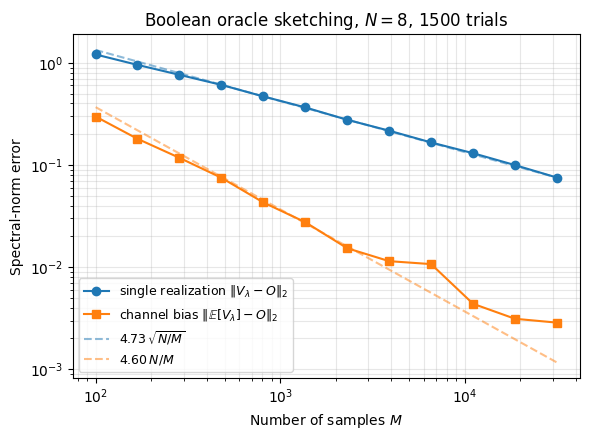

In [15]:
def ideal_oracle(f_table):
    """Diagonal Boolean phase oracle O|x> = (-1)^{f(x)} |x>."""
    return np.diag((-1.0) ** f_table.astype(float))


def sketched_oracle(f_table, x_samples):
    """Numpy reference for V = prod_t exp(i tau f(x_t) |x_t><x_t| / M), tau = pi N.

    Each V_t is diagonal, so the product collapses to a single diagonal:
    V_xx = exp(i pi N m_x f(x)) where m_x is the empirical frequency of x.
    """
    n = f_table.size
    m_total = x_samples.size
    counts = np.bincount(x_samples, minlength=n)
    m = counts / m_total
    return np.diag(np.exp(1j * np.pi * n * m * f_table))


# Single realization at M = 6000
M = 4000
x_samples = np.random.randint(0, N, size=M)
V = sketched_oracle(F_TABLE, x_samples)
O = ideal_oracle(F_TABLE)
err = np.linalg.norm(V - O, ord=2)
print(f"||V - O||_2  at  M={M}, N={N}:  {err:.3e}")

# Sweep M to verify the single-realization vs channel-bias scalings.
M_values = np.unique(np.logspace(2, 4.5, 12, dtype=int))

# n_trials = number of independent random sample sequences λ drawn per M.
n_trials = 1500

single_err = np.empty(M_values.size)
channel_err = np.empty(M_values.size)
for k, M_k in enumerate(M_values):
    Vs = [
        sketched_oracle(F_TABLE, np.random.randint(0, N, size=int(M_k)))
        for _ in range(n_trials)
    ]
    single_err[k] = np.mean([np.linalg.norm(Vk - O, ord=2) for Vk in Vs])
    channel_err[k] = np.linalg.norm(np.mean(Vs, axis=0) - O, ord=2)

# Theoretical guides: single-realization ~ sqrt(N/M); channel bias ~ N/M.
c_single = float(np.median(single_err / np.sqrt(N / M_values)))
c_channel = float(np.median(channel_err * M_values / N))

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.loglog(M_values, single_err, "o-", label=r"single realization $\|V_\lambda - O\|_2$")
ax.loglog(
    M_values, channel_err, "s-", label=r"channel bias $\|\mathbb{E}[V_\lambda] - O\|_2$"
)
ax.loglog(
    M_values,
    c_single * np.sqrt(N / M_values),
    "--",
    color="C0",
    alpha=0.5,
    label=rf"${c_single:.2f}\,\sqrt{{N/M}}$",
)
ax.loglog(
    M_values,
    c_channel * N / M_values,
    "--",
    color="C1",
    alpha=0.5,
    label=rf"${c_channel:.2f}\,N/M$",
)
ax.set_xlabel("Number of samples $M$")
ax.set_ylabel("Spectral-norm error")
ax.set_title(f"Boolean oracle sketching, $N = {N}$, {n_trials} trials")
ax.legend(fontsize=9)
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

We obtain a relatively good agreement between theory and numerics, the single realization is obtains an exellect fit to the linear regression, while the channel bias show cases fluctuation due to high error to signal ration. Moreover, the scaling constants are of order one, demonstrating that the quantum sketching algorithm is useful for practical implementations.

## Extensions

We now extend the basic sketching algorithm to the case where the data points are sampled from a non-uniform distribution. First, we analyze the case where the probability distribution, $p(x)$, is known. In practice, this case is scalable only when $p(x)$ can be defined in terms of $O(\log(N))$ parameters; otherwise, the memory required to store all the probabilities would ruin the exponential memory advantage. In the second extension we consider an unknown probability distribution, where only the range of probabilities is known. We present an implementation of the two cases and test the latter for a two-qubit operation.

### Non-uniform known probability distribution

The construction above assumed the samples $x_t$ are drawn *uniformly* from $[N]$, which let us pick the global scaling $\tau = \pi N$ so that $\tau m_x \to \pi$. When the samples are drawn from a known, possibly non-uniform distribution $p$ on $[N]$ with $p(x) > 0$ everywhere, the same product-and-concentration argument carries through provided we rescale per sample:

$$
V_t \;=\; \exp\!\Bigl(i\,\tfrac{\pi}{p(x_t)}\,f(x_t)\,|x_t\rangle\!\langle x_t|\Big/M\Bigr),
$$

so that the empirical-frequency limit $m_x \to p(x)$ still gives $\pi$ on each active basis state. 

The sample complexity becomes $M = \Theta\!\bigl(N\,\|1/p\|_\infty / \epsilon\bigr)$; the worst-case rescaling appears as an effective $\|1/p\|_\infty$ factor (the maximum value of $1/p(x)$ for $x\in[N]$) that reduces to $N$ for the uniform case.

Below we present a generalization of ``quantum_oracle_sketch_boolean`` by accepting a *per-sample* angle ``thetas[t] = π / (p(x_samples[t]) · M)``; the existing ``apply_basis_phase`` primitive then realizes each $V_t$. ``x_samples`` is assumed pre-filtered to active samples ($f(x_t) = 1$). The function reduces to the uniform Boolean qfunc when $p = 1/N$ (all angles equal $\pi N / M$).

In [16]:
@qfunc
def quantum_oracle_sketch_known_p(
    probs: CArray[CReal],
    x_samples: CArray[CInt],
    qvar: QNum,
) -> None:
    """
    Sketched Boolean phase oracle for a known non-uniform distribution ``p``.

    Args:
        probs: The probabilities of the samples.
        x_samples: The classical input samples.
        qvar: The quantum variable to apply the oracle to.
    """
    repeat(
        count=x_samples.len,
        iteration=lambda t: apply_basis_phase(
            np.pi / (probs[t] * probs.len), x_samples[t], qvar
        ),
    )

### Extension to an unknown probability distribution (via QSVT)

When $p$ is not known in advance the per-sample angle $\pi / p(x_t)$ is unavailable. Suppose, however, that we know *bounds* on the support of $p$: $p_{\min} \le p(x) \le p_{\max}$ on the support, with **condition number** $\kappa = p_{\max}/p_{\min}$. The construction of Zhao et al. handles this case in three stages.

**Sketch with the $p_{\max}$-scaling.** Pick $t = 1/p_{\max}$. Quantum oracle sketching then approximates

$$
U \;=\; \sum_x e^{i\,p(x) f(x)/p_{\max}}\,|x\rangle\!\langle x| \;=\; e^{i\Lambda},
\qquad \Lambda \;:=\; \sum_x \tfrac{p(x) f(x)}{p_{\max}}\,|x\rangle\!\langle x|.
$$

The eigenvalues of $\Lambda$ are $0$ on the $f = 0$ subspace and lie in $[\,1/\kappa,\,1\,]$ on the $f = 1$ subspace.

**Expose $\sin\Lambda$ with a Hadamard test.** Introduce one ancilla qubit $a$ and the gate $S = \mathrm{diag}(-i, 1)$. The unitary

$$
W \;=\; X_a\, S_a\, X_a\, H_a\,(cU^{\dagger})\, X_a\,(cU)\, H_a~~,
$$

which satisfies

$$
\langle 0_a|\,W\,|0_a\rangle \;=\; \frac{U - U^{\dagger}}{2i} \;=\; \sin\Lambda.
$$

So the spectrum of the block-encoded operator is **$0$** on $f = 0$ and **$\sin(p(x)/p_{\max}) \in [\sin(1/\kappa),\,\sin 1]$** on $f = 1$. Crucially, this is a Hermitian operator with eigenvalues in $[-1, 1]$ — the natural domain for a real QSVT polynomial.

**Apply a threshold polynomial via QSVT.** Use the [QSVT](https://github.com/Classiq/classiq-library/blob/main/algorithms/quantum_linear_solvers/qsvt_matrix_inversion/qsvt_matrix_inversion.ipynb) polynomial of Gilyén–Su–Low–Wiebe, [[6]](#ref6) (Polynomial approximation for a threshold function) with threshold $\lambda^{\star} = \sin(1/\kappa)$. It is an even real polynomial $P$ satisfying

- $|P(w)| \le 1$ on $[-1, 1]$,
- $|P(w) - 1| \le \epsilon$ on $[0,\,\lambda^{\star}/2]$ (where the $f = 0$ entries sit),
- $|P(w) + 1| \le \epsilon$ on $[\lambda^{\star},\,1]$ (where the $f = 1$ entries sit),
- degree $d = O(\log(1/\epsilon)/\lambda^{\star})$.

We choose a hyperbolic tangent function (with absolute value of the variable) as an approximate to the ideal (non-smooth) threshold function: 

$$f(w) = s \tanh(a |w| - b \lambda^{\star} / \lambda^{\star})~~,$$

where $a = 4$ and $b=0.5$ are chosen so to minimize rapid changes (reducing the required polynomial order), while when $f(w>\lambda^{\star})\approx -s$, $s=0.95$ is the scale constant to keep $P$ safely within the valid range $[-1, 1]$. This target function constitutes a smooth target function for the QSVT polynomial, enabling an efficient and exact approximation.

Applied to $W$ via QSVT, the block $\langle 0_a | P_{\text{QSVT}}(W, \phi) | 0_a \rangle$ equals $P(\sin\Lambda)$, which is $\epsilon$-close to the target oracle $O = \sum_x (-1)^{f(x)} |x\rangle\!\langle x|$.


The QSVT degree scales as
$$
Q \;=\; O\!\left(\frac{\log(1/\epsilon)}{\sin(1/\kappa)}\right) \;\le\; O\!\bigl(\kappa\,\log(1/\epsilon)\bigr)~~,
$$
while the total sample complexity in the IID case is

$$
M \;=\; O\!\left(\frac{p_{\max}}{p_{\min}^2}\cdot\frac{\log^2(1/\epsilon)}{\epsilon}\right)~~.
$$

Crucially, no classical knowledge of $p$ itself enters: only the bounds $p_{\min}, p_{\max}$ are used, and only to fix $t = 1/p_{\max}$ and the QSVT degree.

We first set up the problem and introduce the utility functions `hadamard_test_W`, which performs a block encoding of $\sin(\Lambda)$, and `proj_W_block`, which is used as both projectors of the QSVT algorithm.

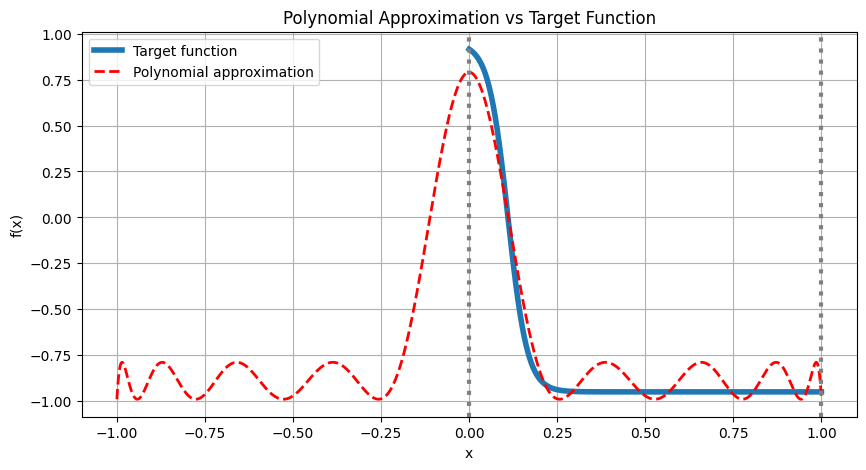

κ = 4.50,  λ* = 0.220,  degree = 18,  fit err = 1.61e-01,  # QSVT phases = 19
Quantum program link: https://platform.classiq.io/circuit/3EcOBdA2ZnG9xHk7POYFM8F9JcN


In [ ]:
# Problem setup: known bounds on the distribution p, but p itself unknown to the algorithm
N_unk = 4
n_qubits_unk = int(np.log2(N_unk))
p_min, p_max = 0.10, 0.45
kappa_unk = p_max / p_min  # condition number of p restricted to its support

# Toy ground-truth p (used ONLY to sample data; the algorithm never accesses it).
p_vec = np.array([0.10, 0.15, 0.30, 0.45])
F_TABLE_unk = np.array([0, 0, 1, 1])  # Boolean target; active basis states: 2, 3 (I⊗Z)


# Compute QSVT phases for the threshold polynomial.
lambda_star = np.sin(1.0 / kappa_unk)

EPS_QSVT = 2e-2
degree_qsvt = int(np.ceil(np.log(1.0 / EPS_QSVT) / lambda_star))
if degree_qsvt % 2 == 1:
    degree_qsvt += 1  # enforce even parity

# Smooth threshold approximant: ≈ +1 near w=0, ≈ -1 for |w| ≥ λ*; tanh transition at λ*/2.
SCALE = 0.95  # keep |P| < 1 strictly inside [-1, 1] for QSP convergence


def threshold_target(w):
    return -SCALE * np.tanh(4.0 * (np.abs(w) - 0.5 * lambda_star) / lambda_star)


poly_coeffs, fit_err = qsp_approximate(
    threshold_target,
    degree=degree_qsvt,
    parity=0,  # even
    interval=[0.0, 1.0],
    plot=True,
)
threshold_phases = qsvt_phases(poly_coeffs)
print(
    f"κ = {kappa_unk:.2f},  λ* = {lambda_star:.3f},  "
    f"degree = {degree_qsvt},  fit err = {fit_err:.2e},  "
    f"# QSVT phases = {len(threshold_phases)}"
)


# Classical sample preparation for the U = e^{iΛ} sketch (Stage 1).
np.random.seed(0)
M_unk = 20  # small M so the QSVT-chain depth stays inside the synthesis timeout
x_samples_unk = np.random.choice(np.arange(N_unk), size=M_unk, p=p_vec)
active_unk = x_samples_unk[F_TABLE_unk[x_samples_unk] == 1].tolist()

# Fixed evolution time t = 1/p_max gives a SINGLE per-sample angle θ = t/M,
# independent of x_t — we don't divide by p(x_t) because p is unknown.
# This is the uniform-θ Boolean sketcher, with the scaling set by the bound p_max
# rather than by 1/N.
theta_unk = 1.0 / (p_max * M_unk)


# Hadamard-test block encoding of sin(Λ) (Stage 2)
@qfunc
def hadamard_test_W(
    theta: CReal,
    x_samples: CArray[CInt],
    qvar: QNum,
    aux_W: QBit,
) -> None:
    """W = X_a · S_a · X_a · H_a · (cU†) · X_a · (cU) · H_a

    Block-encodes sin(Λ) in the |0⟩_{aux_W} subspace:
        ⟨0_{aux_W}| W |0_{aux_W}⟩ = (U − U†)/(2i) = sin(Λ).
    """
    H(aux_W)
    control(aux_W, lambda: quantum_oracle_sketch_boolean(theta, x_samples, qvar))
    X(aux_W)
    control(
        aux_W,
        lambda: invert(lambda: quantum_oracle_sketch_boolean(theta, x_samples, qvar)),
    )
    X(aux_W)
    H(aux_W)
    S(aux_W)  # upto a global phase, gives diag(-i, 1), which is the desired.
    X(aux_W)  # swap |0⟩_a ↔ |1⟩_a so sin Λ lives in the |0⟩_a block


@qfunc
def proj_W_block(aux_W: QBit, flag: QBit) -> None:
    """Flip `flag` when `aux_W` is in |0⟩ — projector onto the W block-encoded subspace."""
    control(aux_W == 0, lambda: X(flag))


# Top-level program: apply the QSVT threshold polynomial to W
@qfunc
def main(
    qvar: Output[QNum],
    aux_W: Output[QBit],
    qsvt_aux: Output[QBit],
) -> None:
    allocate(n_qubits_unk, qvar)
    allocate(1, aux_W)
    allocate(1, qsvt_aux)

    # QSVT chain applied to W; the polynomial P(sin Λ) approximates
    # the target oracle O = Σ_x (-1)^{f(x)} |x⟩⟨x| in the |0⟩_{aux_W} block.
    qsvt(
        phase_seq=threshold_phases.tolist(),
        proj_cnot_1=lambda flag: proj_W_block(aux_W, flag),
        proj_cnot_2=lambda flag: proj_W_block(aux_W, flag),
        u=lambda: hadamard_test_W(theta_unk, active_unk, qvar, aux_W),
        aux=qsvt_aux,
    )


# Increasing the synthesis timeout above the 300 s default to implement the QSVT
qprog_unk = synthesize(main, preferences=Preferences(timeout_seconds=600))
show(qprog_unk)

In the plot above, we compare the even target function to the QSVT polynomial approximation. For better agreement, one can increase the polynomial order, at the expense of an increase in the circuit depth.

#### Verification on a 2-qubit Bell state via Classiq execution

With $f = [0, 0, 1, 1]$ the ideal oracle is $O = I \otimes Z$, the same phase on the most-significant-bit subspace used in the Boolean cell above, so $O$ again maps $|\Phi^+\rangle = (|00\rangle + |11\rangle)/\sqrt{2}$ to $|\Phi^-\rangle = (|00\rangle - |11\rangle)/\sqrt{2}$. The unknown-$p$ pipeline replaces the direct sketched oracle by the QSVT polynomial $P(\sin\Lambda)$ block-encoded in $W$, which approximates $O$ inside the $|0\rangle_{\text{aux\_W}}$ ancilla subspace. 

We prepare $|\Phi^+\rangle$, apply the full QSVT chain, and then run the inverse Bell preparation so that $|\Phi^-\rangle \mapsto |10\rangle$ (`qvar = 1`). Post-selecting on the QSVT block (`aux_W` = `qsvt_aux` = 0$) and measuring `qvar` gives the in-block fidelity $|\langle\Phi^-|\,P_{\text{QSVT}}(W)\,|\Phi^+\rangle|^2$. 

In [21]:
# 2-qubit Bell-state setup for the QSVT-corrected sketch.


@qfunc
def main(
    qvar: Output[QNum],
    aux_W: Output[QBit],
    qsvt_aux: Output[QBit],
) -> None:
    bell = QArray[QBit, 2]()
    allocate(2, qvar)
    allocate(1, aux_W)
    allocate(1, qsvt_aux)

    # W * A * W^{-1}.
    # W: cast qvar -> bell, prep |Φ+⟩, cast back to qvar so qsvt sees a QNum.
    # W^{-1} (auto-generated): cast qvar -> bell, inverse Bell prep
    # (rotates Bell basis to computational basis, |Φ-⟩ → |10⟩), cast back to qvar.
    within_apply(
        within=lambda: (
            bind(qvar, bell),
            H(bell[0]),
            CX(bell[0], bell[1]),
            bind(bell, qvar),
        ),
        apply=lambda: qsvt(
            phase_seq=threshold_phases.tolist(),
            proj_cnot_1=lambda flag: proj_W_block(aux_W, flag),
            proj_cnot_2=lambda flag: proj_W_block(aux_W, flag),
            u=lambda: hadamard_test_W(theta_unk, active_unk, qvar, aux_W),
            aux=qsvt_aux,
        ),
    )


# Same timeout bump as the cell above — the QSVT chain is the same size.
qprog_unk_bell = synthesize(main, preferences=Preferences(timeout_seconds=600))

# printing the circuit metrics, showing that the QSVT chain is indeed the dominant contributor to the depth and gate count
print(
    f"depth = {qprog_unk_bell.transpiled_circuit.depth}, "
    f"width = {qprog_unk_bell.data.width}, "
)

df_unk = sample(qprog_unk_bell, "simulator", num_shots=10_000)

# Post-select on the QSVT block (aux_W = qsvt_aux = 0) and read |Φ-⟩ off qvar = 1.
in_block = df_unk[(df_unk["aux_W"] == 0) & (df_unk["qsvt_aux"] == 0)]
p_block = float(in_block["probability"].sum())
fidelity_unk = (
    float(in_block.loc[in_block["qvar"] == 1, "probability"].sum()) / p_block
    if p_block > 0
    else float("nan")
)
print(f"P(QSVT block, aux_W = qsvt_aux = 0)              :  {p_block:.4f}")
print(f"Fidelity |⟨Φ-|P_QSVT(W)|Φ+⟩|² (post-selected)    :  {fidelity_unk:.4f}")

Submitting job to simulator


depth = 8672, width = 4, 


Job: https://platform.classiq.io/jobs/52ecbba1-a265-4f7d-ad3c-20c71717ef12


P(QSVT block, aux_W = qsvt_aux = 0)              :  0.8016
Fidelity |⟨Φ-|P_QSVT(W)|Φ+⟩|² (post-selected)    :  0.9879


We obtain good fidelity ($\approx 0.98$), with high probability ($p_{\text{block}}\approx 0.8$). This verifies the accuracy of the oracle sketching algorithm. Note however, that the accuracy comes with an associated cost, as an accurate approximation of the threshold function requires a high QSVT order, which in turn, leads to a deep circuit ($\text{circuit depth: }\sim 8500$).

## Summary

Quantum oracle sketching converts a stream of classical samples $(x_t, f(x_t))$ into an approximate coherent oracle $V \approx O_f$ in $\Theta(N/\epsilon)$ samples. We analyzed the sample complexity scaling of the Boolean / uniform case, verifying that the scaling constants are relatively small. Following, we demonstrate the performance of the oracle sketching by analyzing the accuracy of a two-qubit state transformation. Finally, we presented extensions to non-uniform known and unknown probability distributions.

## References

<a id='ref1'></a>
[[1]](#ref1) Zhao, H., Zlokapa, A., Neven, H., Babbush, R., Preskill, J., McClean, J. R., and Huang, H.-Y. Exponential quantum advantage in processing massive classical data. [arXiv:2604.07639 (2026)](https://arxiv.org/abs/2604.07639)

<a id='ref2'></a>
[[2]](#ref2) Huang, H.-Y., Kueng, R., and Preskill, J. *Predicting many properties of a quantum system from very few measurements.* Nature Physics 16, 1050–1057 (2020). https://doi.org/10.1038/s41567-020-0932-7. [arXiv](https://arxiv.org/abs/2002.08953)

<a id='ref3'></a>
[[3]](#ref3) Giovannetti, V., Lloyd, S., and Maccone, L. *Quantum random access memory.* Physical Review Letters 100, 160501 (2008). https://doi.org/10.1103/PhysRevLett.100.160501. [arXiv](https://arxiv.org/abs/0708.1879)

<a id='ref4'></a>
[[4]](#ref4) Gilyén, A., Su, Y., Low, G. H., and Wiebe, N. *Quantum singular value transformation and beyond: exponential improvements for quantum matrix arithmetics.* In Proceedings of the 51st Annual ACM SIGACT Symposium on Theory of Computing, 193–204 (2019). https://doi.org/10.1145/3313276.3316366. [arXiv](https://arxiv.org/abs/1806.01838).

<a id='ref5'></a>
[[5]](#ref5) Harrow, A. W., Hassidim, A., and Lloyd, S. *Quantum algorithm for linear systems of equations.* Physical Review Letters 103, 150502 (2009). https://doi.org/10.1103/PhysRevLett.103.150502. [arXiv](https://arxiv.org/abs/0811.3171).

<a id='ref6'></a>
[[6]](#ref6) Martyn, J. M., Rossi, Z. M., Tan, A. K., and Chuang, I. L. *Grand unification of quantum algorithms.* PRX Quantum 2, 040203 (2021). https://doi.org/10.1103/PRXQuantum.2.040203. [arXiv](https://arxiv.org/abs/2105.02859).